In [ ]:
# K-Means on CE Survey → spending personas
# Trains Logistic Regression, Random Forest, XGBoost to predict risk_tolerance (conservative/moderate/aggressive) from raw Census features
# Compares models, saves the best one for the API

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [18]:
# CE SURVEY K-MEANS

def run_ce_kmeans(filepath='data/processed/ce_survey_features.csv'):
    """
    K-Means clustering on CE Survey to create spending personas.
    Uses budget features: savings_rate, needs_ratio, wants_ratio,
    spending ratios, budget_health_score, etc.
    """
    print("  CE SURVEY K-MEANS — SPENDING PERSONAS")

    # Load
    ce = pd.read_csv(filepath)
    print(f"  Loaded: {ce.shape}")

    # Select clustering features
    cluster_cols = [c for c in ce.columns if c.startswith('ratio_') or
                    c in ['savings_rate', 'needs_ratio', 'wants_ratio',
                           'budget_health_score', 'income_percentile']]

    # Keep only numeric, drop NaN
    X = ce[cluster_cols].apply(pd.to_numeric, errors='coerce')
    valid_mask = X.notnull().all(axis=1) & (X != 0).any(axis=1)
    X = X[valid_mask].copy()
    ce_clean = ce.loc[valid_mask].copy()

    print(f"  Features: {cluster_cols}")
    print(f"  Rows after cleaning: {len(X)}")

    # Scale
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=cluster_cols, index=X.index)

    # Find optimal K (2-8 for spending — don't need as many as Census)
    print("\n  Finding optimal K")
    results = {'k': [], 'silhouette': [], 'inertia': []}

    for k in range(2, 9):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        lab = km.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, lab)
        results['k'].append(k)
        results['silhouette'].append(sil)
        results['inertia'].append(km.inertia_)
        print(f"    K={k}: Silhouette={sil:.4f}")

    best_k = results['k'][np.argmax(results['silhouette'])]
    print(f"\n  ★ Best K = {best_k}")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(results['k'], results['inertia'], 'bo-', lw=2)
    axes[0].axvline(best_k, color='red', ls='--', label=f'K={best_k}')
    axes[0].set(xlabel='K', ylabel='Inertia', title='Elbow Method — CE Survey')
    axes[0].legend()

    colors = ['red' if k == best_k else 'steelblue' for k in results['k']]
    axes[1].bar(results['k'], results['silhouette'], color=colors)
    axes[1].set(xlabel='K', ylabel='Silhouette', title='Silhouette — CE Survey')
    plt.tight_layout()
    plt.savefig('reports/figures/ce_optimal_k.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Run final K-Means
    km_final = KMeans(n_clusters=best_k, random_state=42, n_init=20, max_iter=500)
    labels = km_final.fit_predict(X_scaled)

    # Profile spending personas
    ce_clean['spending_cluster'] = labels
    profiles = ce_clean.groupby('spending_cluster')[cluster_cols].mean()

    print(f"\n  Spending cluster profiles:")
    print(profiles.round(3).to_string())

    # Auto-name spending personas
    persona_names = {}
    for cid in profiles.index:
        r = profiles.loc[cid]
        savings = r.get('savings_rate', 0)
        housing = r.get('ratio_housing', 0)
        needs = r.get('needs_ratio', 0)
        health = r.get('budget_health_score', 0)

        if savings > 0.35 and health > 0.5:
            name = "Excellent Saver"
        elif savings > 0.20 and needs < 0.55:
            name = "Balanced Budgeter"
        elif housing > 0.35:
            name = "Housing Burdened"
        elif savings < 0.05:
            name = "Minimal Saver"
        elif savings < 0:
            name = "Over-Spender"
        elif needs > 0.60:
            name = "Needs Heavy"
        else:
            name = "Moderate Spender"

        persona_names[cid] = name

    ce_clean['spending_persona'] = ce_clean['spending_cluster'].map(persona_names)

    print(f"\n  ★ Spending Personas:")
    for cid, name in persona_names.items():
        count = (labels == cid).sum()
        print(f"    Cluster {cid}: {name} — {count:,} households")

    # Visualize
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(10, 7))
    for cid, color in zip(np.unique(labels), plt.cm.Set2(np.linspace(0, 1, best_k))):
        mask = labels == cid
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color],
                   label=persona_names[cid], alpha=0.5, s=20)
    ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
           ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
           title='CE Survey — Spending Personas (PCA)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('reports/figures/ce_spending_pca.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Heatmap
    fig, ax = plt.subplots(figsize=(14, 5))
    pn = pd.DataFrame(MinMaxScaler().fit_transform(profiles), columns=cluster_cols,
                       index=[persona_names[i] for i in profiles.index])
    sns.heatmap(pn, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title('CE Spending Persona Profiles')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('reports/figures/ce_spending_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Save
    ce_clean.to_csv('data/processed/ce_spending_personas.csv', index=False)
    joblib.dump(km_final, 'data/processed/ce_kmeans_model.pkl')
    joblib.dump(scaler, 'data/processed/ce_kmeans_scaler.pkl')
    print(f"\n  ✓ Saved: data/processed/ce_spending_personas.csv")

    return ce_clean, profiles, persona_names


def prepare_classification_data(filepath='data/processed/census_clustered.csv'):
    """
    Prepare X (raw demographics) and y (risk_tolerance) for classification.
    
    The goal: train a model that takes RAW user inputs (age, education, 
    marital status, etc.) and predicts their risk tier — so the Streamlit
    app can classify new users without re-running K-Means + feature engineering.
    """
    print("  PREPARING CLASSIFICATION DATA")

    df = pd.read_csv(filepath)
    print(f"  Loaded: {df.shape}")

    # Target: risk_tolerance (from K-Means → risk_tolerance_score → binned)
    # Drop rows where risk_tolerance is NaN
    df = df.dropna(subset=['risk_tolerance'])
    print(f"  Target distribution:\n{df['risk_tolerance'].value_counts().to_string()}")

    # Encode target
    le = LabelEncoder()
    y = le.fit_transform(df['risk_tolerance'])
    print(f"  Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")

    # Features: use the ORIGINAL Census columns (not engineered ones)
    # These are what a new user would provide in the app
    raw_features = [
        'AAGE',           # age
        'AHGA',           # education
        'ACLSWKR',        # class of worker
        'AMARITL',        # marital status
        'ASEX',           # sex
        'AHRSPAY',        # wage per hour
        'WKSWORK',        # weeks worked
        'CAPGAIN',        # capital gains
        'GAPLOSS',        # capital losses
        'DIVVAL',         # dividends
        'FILESTAT',       # tax filer status
        'AMJOCC',         # major occupation
        'AMJIND',         # major industry
    ]
    raw_features = [f for f in raw_features if f in df.columns]
    print(f"  Raw features ({len(raw_features)}): {raw_features}")

    X = df[raw_features].copy()

    # Encode categoricals
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    print(f"  Categorical: {cat_cols}")
    print(f"  Numeric: {num_cols}")

    # Label encode each categorical column
    encoders = {}
    for col in cat_cols:
        X[col] = X[col].astype(str).str.strip()
        enc = LabelEncoder()
        X[col] = enc.fit_transform(X[col])
        encoders[col] = enc

    # Fill NaN in numerics
    for col in num_cols:
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

    print(f"  Final X shape: {X.shape}")
    print(f"  Final y shape: {y.shape}")

    return X, y, le, encoders, raw_features

In [20]:
def train_and_compare_models(X, y, le):
    """
    Train Logistic Regression, Random Forest, and XGBoost.
    Compare using accuracy, F1, cross-validation.
    """
    print("  TRAINING & COMPARING MODELS")

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"  Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

    # Scale for Logistic Regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ---- Model 1: Logistic Regression ----
    print("\n  [1] Logistic Regression ")
    lr = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
    lr.fit(X_train_scaled, y_train)
    lr_pred = lr.predict(X_test_scaled)
    lr_acc = accuracy_score(y_test, lr_pred)
    lr_f1 = f1_score(y_test, lr_pred, average='weighted')
    lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    print(f"    Accuracy: {lr_acc:.4f} | F1: {lr_f1:.4f} | CV Accuracy: {lr_cv:.4f}")

    # ---- Model 2: Random Forest ----
    print("\n  [2] Random Forest ")
    rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_acc = accuracy_score(y_test, rf_pred)
    rf_f1 = f1_score(y_test, rf_pred, average='weighted')
    rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy').mean()
    print(f"    Accuracy: {rf_acc:.4f} | F1: {rf_f1:.4f} | CV Accuracy: {rf_cv:.4f}")

    # ---- Model 3: XGBoost ----
    print("\n  [3] XGBoost ")
    try:
        from xgboost import XGBClassifier
        xgb = XGBClassifier(
            n_estimators=300, max_depth=8, learning_rate=0.1,
            random_state=42, n_jobs=-1, eval_metric='mlogloss',
            use_label_encoder=False
        )
        xgb.fit(X_train, y_train)
        xgb_pred = xgb.predict(X_test)
        xgb_acc = accuracy_score(y_test, xgb_pred)
        xgb_f1 = f1_score(y_test, xgb_pred, average='weighted')
        xgb_cv = cross_val_score(xgb, X_train, y_train, cv=5, scoring='accuracy').mean()
        print(f"    Accuracy: {xgb_acc:.4f} | F1: {xgb_f1:.4f} | CV Accuracy: {xgb_cv:.4f}")
        xgb_available = True
    except ImportError:
        print("    XGBoost not installed. Run: pip install xgboost")
        xgb_available = False
        xgb_acc = xgb_f1 = xgb_cv = 0

    # ---- Comparison ----
    results = {
        'Model': ['Logistic Regression', 'Random Forest'],
        'Accuracy': [lr_acc, rf_acc],
        'F1 (weighted)': [lr_f1, rf_f1],
        'CV Accuracy': [lr_cv, rf_cv]
    }
    models = {'Logistic Regression': (lr, scaler, True),
              'Random Forest': (rf, None, False)}

    if xgb_available:
        results['Model'].append('XGBoost')
        results['Accuracy'].append(xgb_acc)
        results['F1 (weighted)'].append(xgb_f1)
        results['CV Accuracy'].append(xgb_cv)
        models['XGBoost'] = (xgb, None, False)

    results_df = pd.DataFrame(results)
    print(f" MODEL COMPARISON ")
    print(results_df.to_string(index=False))

    # Pick best model
    best_idx = results_df['F1 (weighted)'].idxmax()
    best_name = results_df.loc[best_idx, 'Model']
    best_model, best_scaler, needs_scaling = models[best_name]
    print(f"\n  ★ Best model: {best_name} (F1={results_df.loc[best_idx, 'F1 (weighted)']:.4f})")

    # ---- Visualization: Model Comparison ----
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Bar chart comparison
    x = np.arange(len(results_df))
    w = 0.25
    axes[0].bar(x - w, results_df['Accuracy'], w, label='Accuracy', color='steelblue')
    axes[0].bar(x, results_df['F1 (weighted)'], w, label='F1', color='coral')
    axes[0].bar(x + w, results_df['CV Accuracy'], w, label='CV Accuracy', color='seagreen')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(results_df['Model'], rotation=15)
    axes[0].set_title('Model Comparison')
    axes[0].legend()
    axes[0].set_ylim(0, 1.05)

    # Confusion matrix for best model
    if best_name == 'Logistic Regression':
        best_pred = lr_pred
    elif best_name == 'Random Forest':
        best_pred = rf_pred
    else:
        best_pred = xgb_pred

    cm = confusion_matrix(y_test, best_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[1].set(xlabel='Predicted', ylabel='Actual',
                title=f'Confusion Matrix — {best_name}')

    # Feature importance (RF or XGBoost)
    if best_name in ['Random Forest', 'XGBoost']:
        imp = pd.Series(best_model.feature_importances_, index=X.columns)
        imp = imp.sort_values(ascending=True).tail(10)
        imp.plot(kind='barh', ax=axes[2], color='teal')
        axes[2].set_title(f'Top 10 Features — {best_name}')
    else:
        # For LR, show coefficient magnitudes
        coef_means = np.abs(lr.coef_).mean(axis=0)
        imp = pd.Series(coef_means, index=X.columns).sort_values(ascending=True).tail(10)
        imp.plot(kind='barh', ax=axes[2], color='teal')
        axes[2].set_title('Top 10 Features — Logistic Regression')

    plt.tight_layout()
    plt.savefig('reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ---- Detailed Classification Report (best model) ----
    print(f"\n  Classification Report — {best_name}:")
    print(classification_report(y_test, best_pred, target_names=le.classes_))

    return results_df, best_model, best_name, best_scaler, needs_scaling, le, X_test, y_test


def plot_per_class_metrics(y_test, y_pred, le, model_name, save_path=None):
    """Per-class precision, recall, F1 bar chart."""
    from sklearn.metrics import precision_recall_fscore_support

    prec, rec, f1, sup = precision_recall_fscore_support(y_test, y_pred, labels=range(len(le.classes_)))

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(le.classes_))
    w = 0.25
    ax.bar(x - w, prec, w, label='Precision', color='steelblue')
    ax.bar(x, rec, w, label='Recall', color='coral')
    ax.bar(x + w, f1, w, label='F1', color='seagreen')
    ax.set_xticks(x)
    ax.set_xticklabels(le.classes_)
    ax.set_title(f'Per-Class Metrics — {model_name}')
    ax.legend()
    ax.set_ylim(0, 1.1)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

 CE K-MEANS and SUPERVISED CLASSIFICATION
  CE SURVEY K-MEANS — SPENDING PERSONAS
  Loaded: (23125, 849)
  Features: ['income_percentile', 'savings_rate', 'ratio_food_home', 'ratio_food_away', 'ratio_housing', 'ratio_utilities', 'ratio_transportation', 'ratio_healthcare', 'ratio_entertainment', 'ratio_apparel', 'ratio_education', 'ratio_insurance_pension', 'needs_ratio', 'wants_ratio', 'budget_health_score']
  Rows after cleaning: 23125

  Finding optimal K
    K=2: Silhouette=0.6260
    K=3: Silhouette=0.4825
    K=4: Silhouette=0.2830
    K=5: Silhouette=0.2868
    K=6: Silhouette=0.2906
    K=7: Silhouette=0.3021
    K=8: Silhouette=0.3091

  ★ Best K = 2


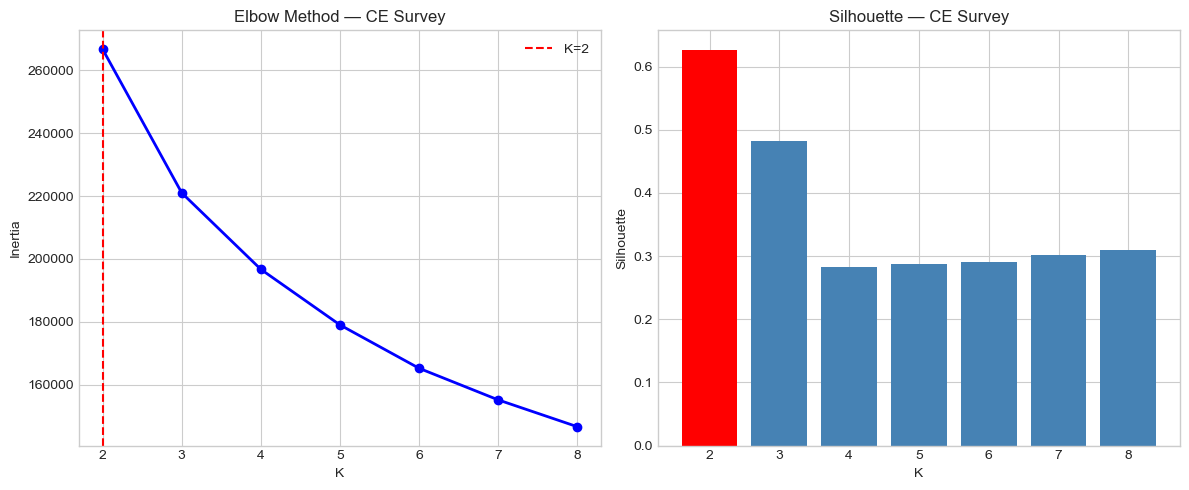


  Spending cluster profiles:
                  income_percentile  savings_rate  ratio_food_home  ratio_food_away  ratio_housing  ratio_utilities  ratio_transportation  ratio_healthcare  ratio_entertainment  ratio_apparel  ratio_education  ratio_insurance_pension  needs_ratio  wants_ratio  budget_health_score
spending_cluster                                                                                                                                                                                                                                                                        
0                             0.536         0.439            0.013            0.036          0.214            0.043                  0.07             0.051                0.021          0.011            0.005                    0.053        0.443        0.073                0.243
1                             0.156        -0.910            0.112            0.275          1.165            0.346            

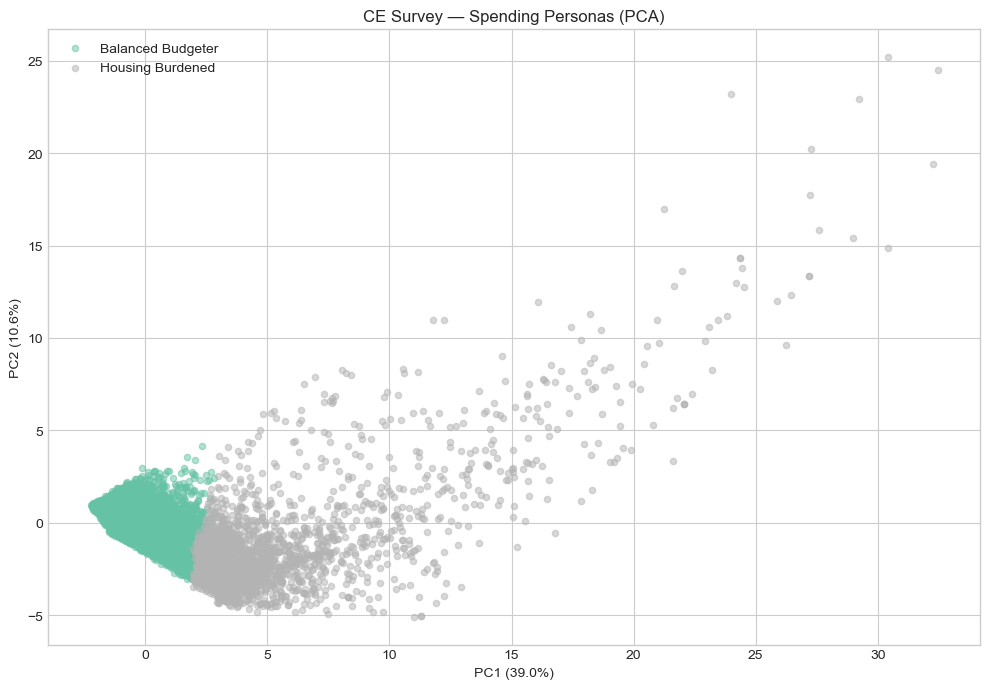

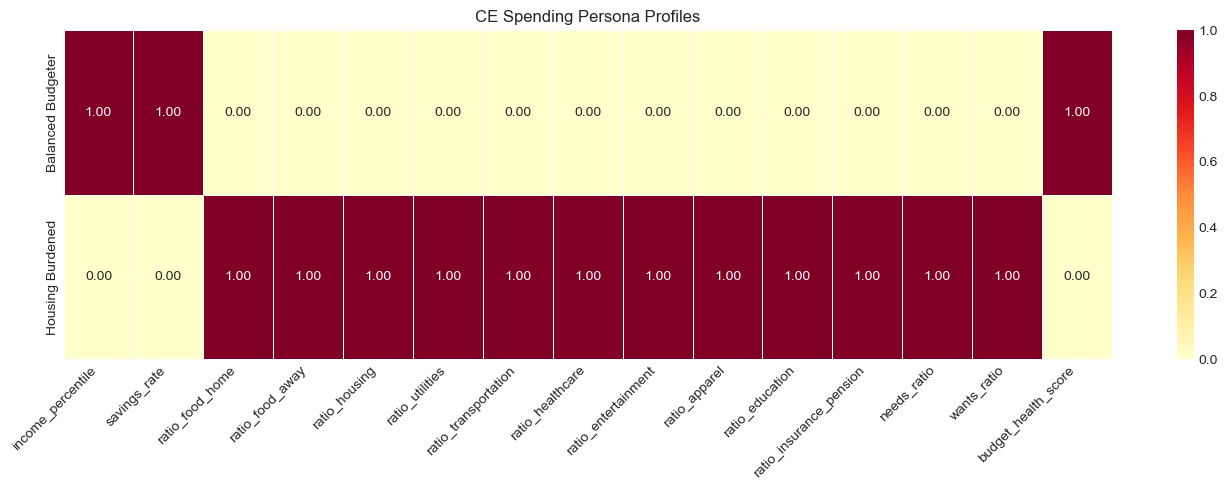


  ✓ Saved: data/processed/ce_spending_personas.csv
  PREPARING CLASSIFICATION DATA
  Loaded: (199523, 65)
  Target distribution:
risk_tolerance
moderate        127142
aggressive       47439
conservative     24942
  Classes: {'aggressive': 0, 'conservative': 1, 'moderate': 2}
  Raw features (13): ['AAGE', 'AHGA', 'ACLSWKR', 'AMARITL', 'ASEX', 'AHRSPAY', 'WKSWORK', 'CAPGAIN', 'GAPLOSS', 'DIVVAL', 'FILESTAT', 'AMJOCC', 'AMJIND']
  Categorical: ['AHGA', 'ACLSWKR', 'AMARITL', 'ASEX', 'FILESTAT', 'AMJOCC', 'AMJIND']
  Numeric: ['AAGE', 'AHRSPAY', 'WKSWORK', 'CAPGAIN', 'GAPLOSS', 'DIVVAL']
  Final X shape: (199523, 13)
  Final y shape: (199523,)
  TRAINING & COMPARING MODELS
  Train: 159,618 | Test: 39,905

  [1] Logistic Regression 
    Accuracy: 0.8062 | F1: 0.7868 | CV Accuracy: 0.8055

  [2] Random Forest 
    Accuracy: 0.9582 | F1: 0.9582 | CV Accuracy: 0.9568

  [3] XGBoost 
    Accuracy: 0.9587 | F1: 0.9587 | CV Accuracy: 0.9564
 MODEL COMPARISON 
              Model  Accuracy  F1 (we

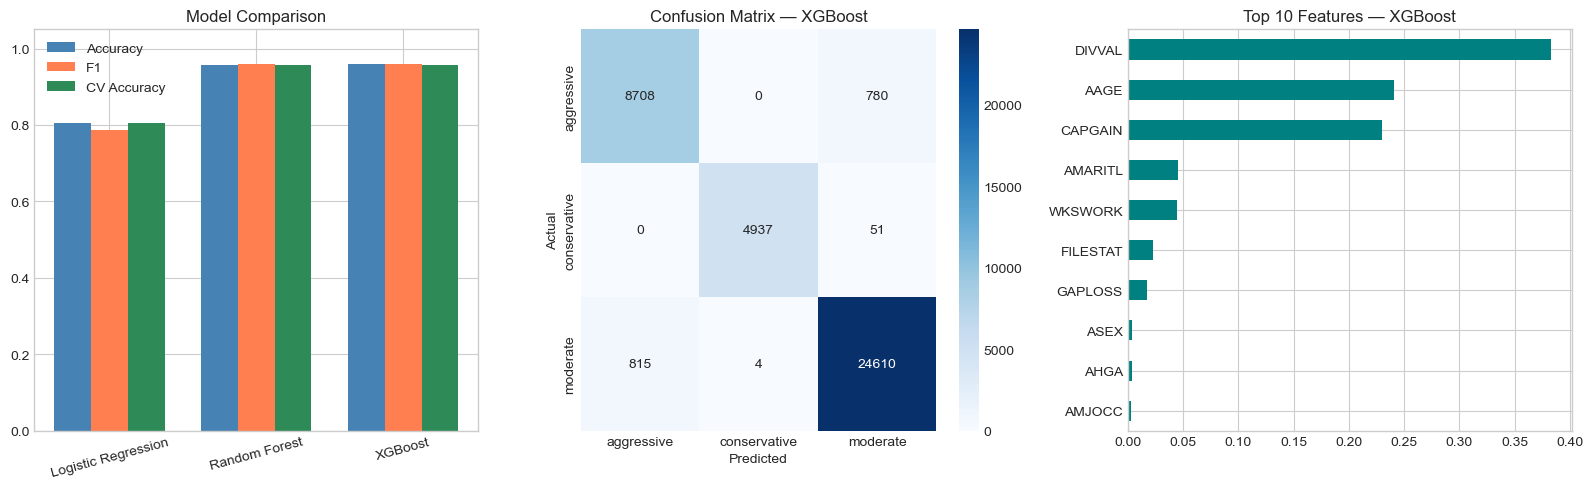


  Classification Report — XGBoost:
              precision    recall  f1-score   support

  aggressive       0.91      0.92      0.92      9488
conservative       1.00      0.99      0.99      4988
    moderate       0.97      0.97      0.97     25429

    accuracy                           0.96     39905
   macro avg       0.96      0.96      0.96     39905
weighted avg       0.96      0.96      0.96     39905



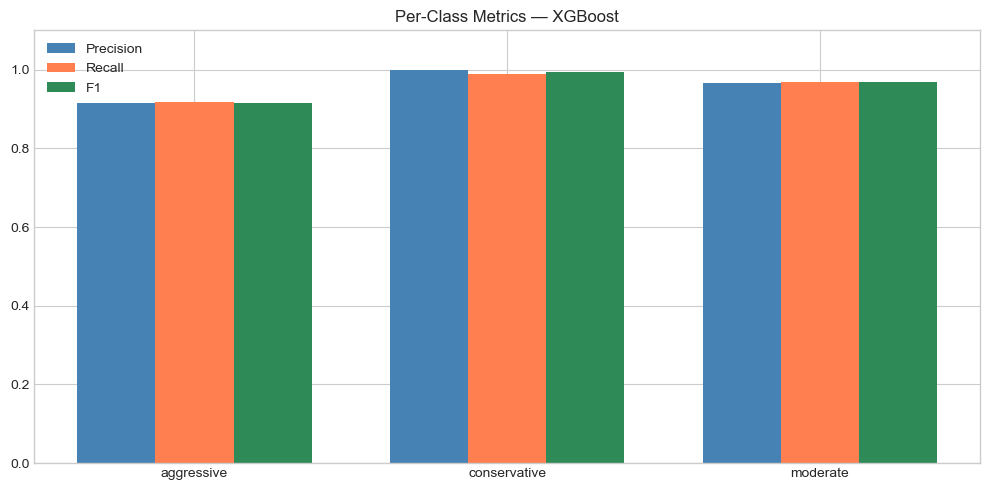



SAVING

  Best model (XGBoost) → data/processed/best_classifier.pkl
  Label encoder → data/processed/label_encoder.pkl
  Feature encoders → data/processed/feature_encoders.pkl
  Model comparison → data/processed/model_comparison.csv
  CE spending personas → data/processed/ce_spending_personas.csv


In [22]:
def main():
    os.makedirs('data/processed', exist_ok=True)
    os.makedirs('reports/figures', exist_ok=True)

    print(" CE K-MEANS and SUPERVISED CLASSIFICATION")

    # ---- A: CE Survey K-Means ----
    ce_clean, ce_profiles, ce_personas = run_ce_kmeans()

    # ---- B: Supervised Classification ----
    X, y, le, encoders, raw_features = prepare_classification_data()
    results_df, best_model, best_name, best_scaler, needs_scaling, le, X_test, y_test = \
        train_and_compare_models(X, y, le)

    # Per-class metrics for best model
    if best_name == 'Logistic Regression':
        best_pred = best_model.predict(best_scaler.transform(X_test))
    else:
        best_pred = best_model.predict(X_test)

    plot_per_class_metrics(y_test, best_pred, le, best_name,
                           save_path='reports/figures/per_class_metrics.png')

    # ---- Save ----
    print(f"\n\nSAVING\n")

    joblib.dump(best_model, 'data/processed/best_classifier.pkl')
    joblib.dump(le, 'data/processed/label_encoder.pkl')
    joblib.dump(encoders, 'data/processed/feature_encoders.pkl')
    if best_scaler:
        joblib.dump(best_scaler, 'data/processed/classifier_scaler.pkl')

    # Save feature list (so the API knows what inputs to expect)
    pd.Series(raw_features).to_csv('data/processed/classifier_features.csv', index=False)

    results_df.to_csv('data/processed/model_comparison.csv', index=False)

    print(f"  Best model ({best_name}) → data/processed/best_classifier.pkl")
    print(f"  Label encoder → data/processed/label_encoder.pkl")
    print(f"  Feature encoders → data/processed/feature_encoders.pkl")
    print(f"  Model comparison → data/processed/model_comparison.csv")
    print(f"  CE spending personas → data/processed/ce_spending_personas.csv")

    return {
        'ce_personas': ce_personas,
        'best_model': best_model,
        'best_name': best_name,
        'label_encoder': le,
        'results': results_df,
    }


if __name__ == '__main__':
    results = main()